# 05 Coverage

This notebook introduces the interval-first coverage API in a simple order:

- start with `Orbit` objects only
- compute global coverage on a latitude-adaptive grid
- zoom into a regional target set
- add a couple of common constraints
- finish with tabulated ephemeris inputs

All baseline examples below use only line of sight with `elevation >= 0 deg`.
We keep the default `interpolation="cubic"` throughout unless noted otherwise.


In [1]:
# Ensure local package import when running directly from examples/.
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parent if Path.cwd().name == "examples" else Path.cwd().resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))


In [2]:
from dataclasses import replace

import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np
from astropy.time import Time

from nstk.coverage import (
    BBoxDomain,
    CoverageTargets,
    CoverageTimeline,
    IntervalCoverage,
    LatitudeAdaptiveSampler,
    LatitudeLongitudeSampler,
    MinAccessDurationConstraint,
    Observer,
    RangeConstraint,
)
from nstk.plotting import LIGHT_DETAILED
from nstk.plotting.map import ExtentConfig
from nstk.propagation import Orbit, build_walker_constellation


## 1. Orbit-Only Setup

We start with a small Walker-style constellation built entirely from `Orbit` objects.
That keeps the first coverage examples focused on the coverage API rather than on observer construction.


In [3]:
epoch = Time("2026-01-01T00:00:00", scale="utc")

seed_orbit = Orbit.from_kepler_two_body(
    epoch=epoch,
    a=6_878_000.0,
    e=0.001,
    i=np.deg2rad(53.0),
    raan=0.0,
    argp=0.0,
    anomaly=0.0,
    anomaly_type="mean",
)

orbits = build_walker_constellation(
    seed_orbit,
    total_satellites=10,
    num_planes=5,
    phasing=1,
)

timeline = CoverageTimeline.absolute(
    epoch + np.arange(0.0, 12.0 * 3600.0 + 300.0, 300.0) * u.s,
    label="12 hour tutorial window",
)

len(orbits), timeline.seconds.size


(10, 145)

`IntervalCoverage.compute(...)` and `IntervalCoverage.from_orbits(...)` default to `interpolation="cubic"`.
That setting controls the exact interval solver between analysis samples, and it is the default we use in this notebook.
Only switch to `interpolation="linear"` if you intentionally want piecewise-linear motion between samples.


## 2. Worldwide Coverage On A Latitude-Adaptive Grid

For the global example we use a latitude-adaptive sampler.
It keeps the equator dense and reduces the number of longitude points toward the poles, which is closer to the way STK-style coverage grids are usually laid out.


In [4]:
targets_global = CoverageTargets.global_earth(
    sampler=LatitudeAdaptiveSampler(nlats=61, nlons_equator=121),
)

coverage_global = IntervalCoverage.from_orbits(
    orbits=orbits,
    timeline=timeline,
    targets=targets_global,
)

targets_global.n_targets, coverage_global.interpolation


(4623, 'cubic')

In [5]:
global_access = coverage_global.access_duration(min_assets=1, normalize="day", unit="hours")
global_two_asset = coverage_global.access_duration(min_assets=2, normalize="day", unit="hours")
global_max_asset = coverage_global.max_asset()
global_mtta = coverage_global.mtta(min_assets=1, unit="minutes")

{
    "n_observers": len(orbits),
    "n_global_targets": targets_global.n_targets,
    "access_hours_per_day": global_access.summary(),
    "two_asset_hours_per_day": global_two_asset.summary(),
    "max_asset": global_max_asset.summary(),
    "mtta_minutes": global_mtta.summary(),
}


{'n_observers': 10,
 'n_global_targets': 4623,
 'access_hours_per_day': {'min': 0.0,
  'max': 24.265127074942253,
  'mean': 15.628385785996121,
  'std': 5.407980480121807},
 'two_asset_hours_per_day': {'min': 0.0,
  'max': 6.981437683105469,
  'mean': 2.0092321375024156,
  'std': 2.19066984449002},
 'max_asset': {'min': 0.0,
  'max': 2.0,
  'mean': 1.6026389790179536,
  'std': 0.5429922075058407},
 'mtta_minutes': {'min': 3.062851175769018,
  'max': 104.71152491362864,
  'mean': 10.318661877536439,
  'std': 9.798875502393575}}

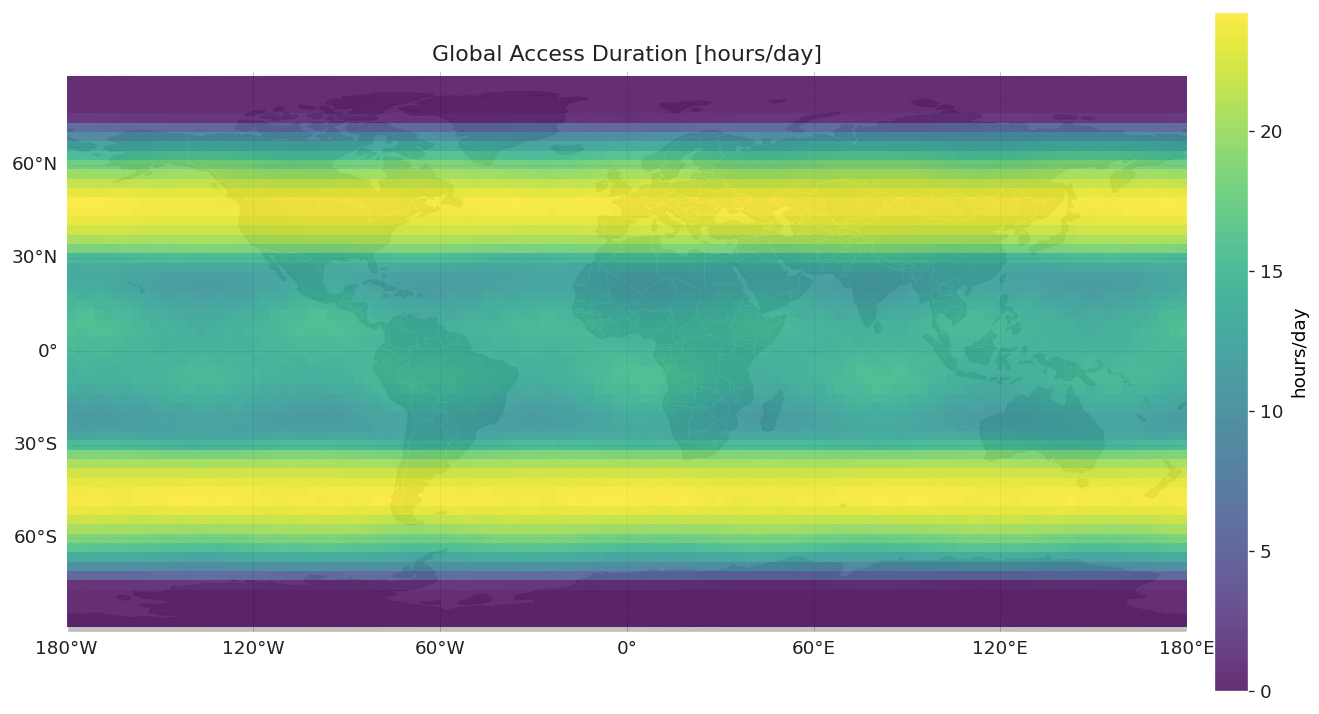

In [6]:
fig, _, _, _ = global_access.plot(
    map_cfg=LIGHT_DETAILED,
    title="Global Access Duration [hours/day]",
    cmap="viridis",
)
plt.show()


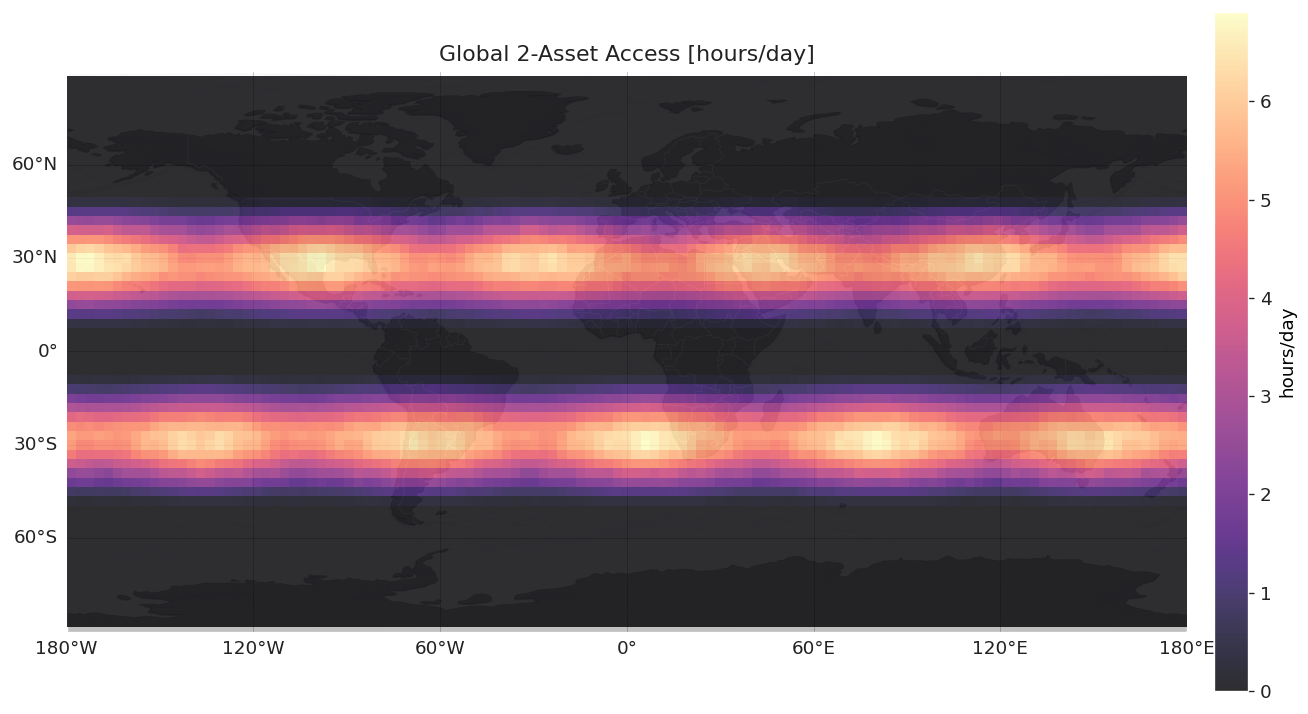

In [7]:
fig, _, _, _ = global_two_asset.plot(
    map_cfg=LIGHT_DETAILED,
    title="Global 2-Asset Access [hours/day]",
    cmap="magma",
)
plt.show()


## 3. Regional Area Coverage On A Structured Grid

Once the global picture looks sensible, it is often useful to switch to a structured regional grid.
That gives you dense rectangular rasters and makes local gradients easier to read.


In [8]:
region_domain = BBoxDomain(
    west_deg=-125.0,
    east_deg=-66.0,
    south_deg=24.0,
    north_deg=50.0,
)

targets_region = CoverageTargets.from_domain(
    region_domain,
    sampler=LatitudeLongitudeSampler(nlats=81, nlons=161),
)

region_map_cfg = replace(
    LIGHT_DETAILED,
    extent=ExtentConfig(global_map=False, extent=(-130.0, -60.0, 20.0, 55.0)),
)

coverage_region = IntervalCoverage.from_orbits(
    orbits=orbits,
    timeline=timeline,
    targets=targets_region,
)

region_access = coverage_region.access_duration(min_assets=1, normalize="day", unit="hours")
region_two_asset = coverage_region.access_duration(min_assets=2, normalize="day", unit="hours")

{
    "n_region_targets": targets_region.n_targets,
    "access_hours_per_day": region_access.summary(),
    "two_asset_hours_per_day": region_two_asset.summary(),
}


{'n_region_targets': 13041,
 'access_hours_per_day': {'min': 11.55563481648763,
  'max': 24.251061900969475,
  'mean': 19.63386342006317,
  'std': 4.204043578737216},
 'two_asset_hours_per_day': {'min': 0.0,
  'max': 7.010024282667372,
  'mean': 3.6477132197687876,
  'std': 2.1798926620134487}}

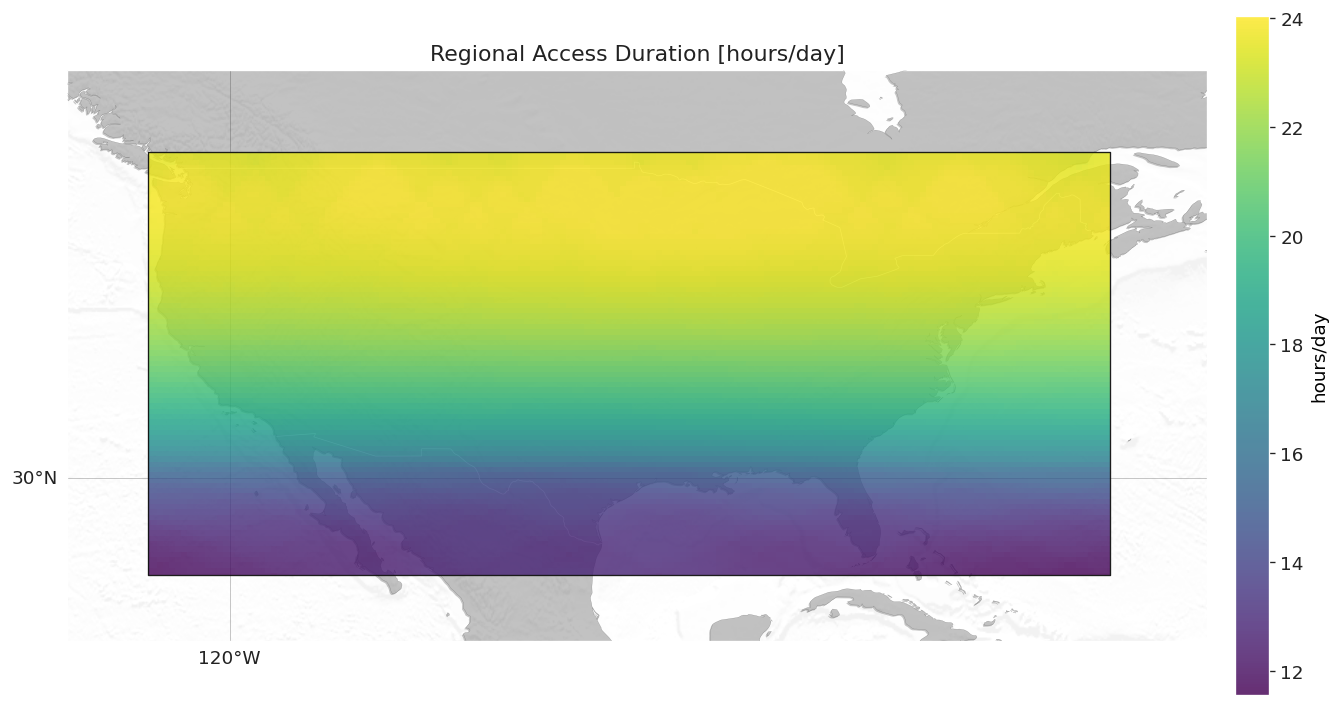

In [9]:
fig, _, _, _ = region_access.plot(
    map_cfg=region_map_cfg,
    title="Regional Access Duration [hours/day]",
    cmap="viridis",
    vmax=np.nanpercentile(region_access.values, 97.0),
)
plt.show()


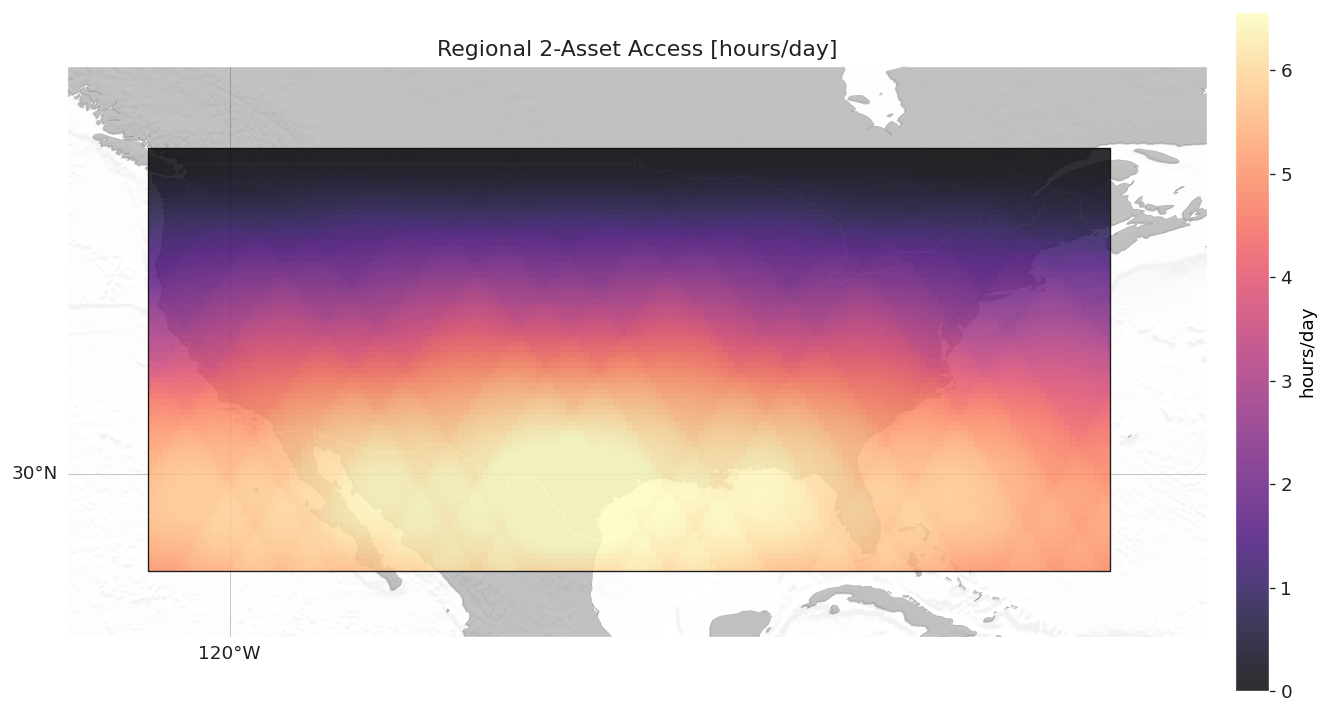

In [10]:
fig, _, _, _ = region_two_asset.plot(
    map_cfg=region_map_cfg,
    title="Regional 2-Asset Access [hours/day]",
    cmap="magma",
    vmax=np.nanpercentile(region_two_asset.values, 97.0),
)
plt.show()


## 4. Add A Couple Of Common Constraints

The baseline examples above use only line of sight.
Now we add two common extra filters on top of that:

- a maximum slant range
- a minimum access duration

Because `with_constraints(...)` works from the computed interval store, we can keep the same target set and reuse the existing coverage object.


In [11]:
constrained_region = coverage_region.with_constraints(
    [
        RangeConstraint(max_m=3_000_000.0),
        MinAccessDurationConstraint(min_seconds=300.0),
    ]
)

constrained_access = constrained_region.access_duration(min_assets=1, normalize="day", unit="hours")

{
    "baseline_mean_hours_per_day": region_access.reduce_targets("mean"),
    "constrained_mean_hours_per_day": constrained_access.reduce_targets("mean"),
    "constrained_summary": constrained_access.summary(),
}


{'baseline_mean_hours_per_day': 19.240275840520464,
 'constrained_mean_hours_per_day': 13.452467388532522,
 'constrained_summary': {'min': 7.147018564267577,
  'max': 19.180584112397916,
  'mean': 13.768307862574542,
  'std': 3.527904643188905}}

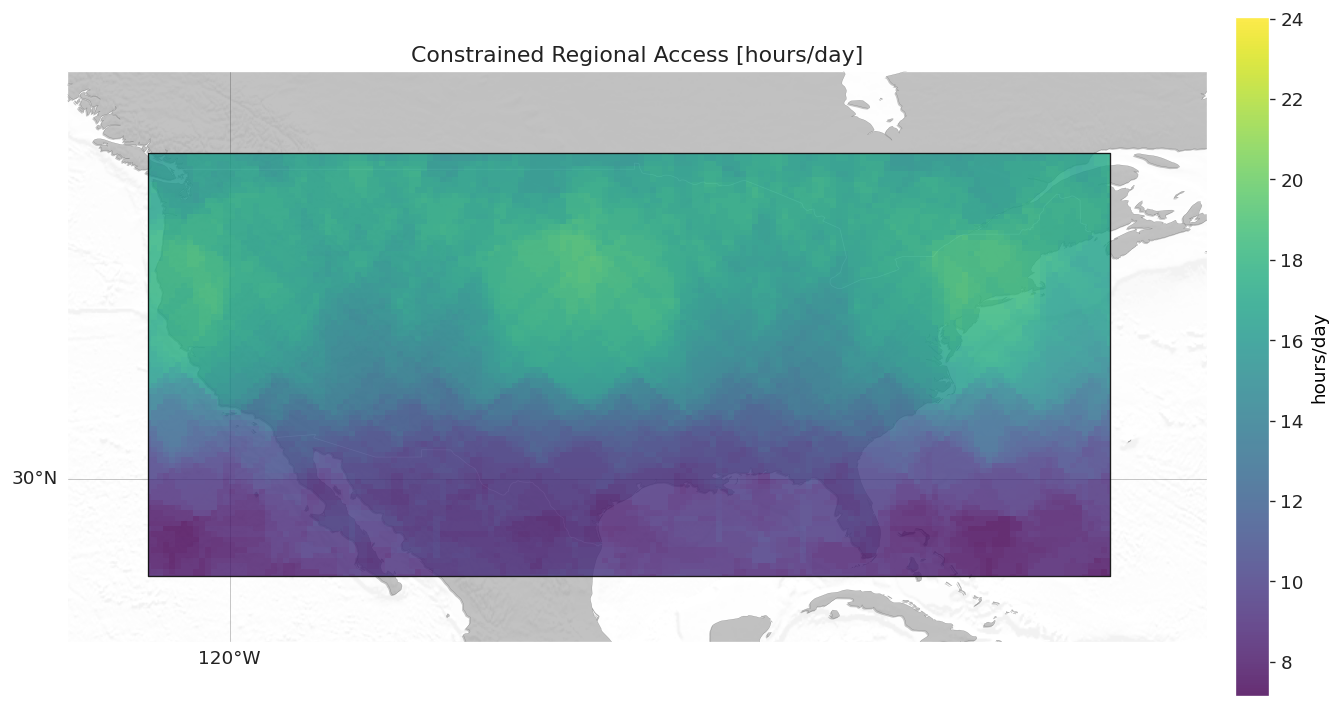

In [12]:
fig, _, _, _ = constrained_access.plot(
    map_cfg=region_map_cfg,
    title="Constrained Regional Access [hours/day]",
    cmap="viridis",
    vmax=np.nanpercentile(region_access.values, 97.0),
)
plt.show()


## 5. Non-Orbit Ephemeris Inputs

Once the orbit-only workflow is clear, switching to external ephemeris inputs is straightforward.

- Use `Observer.from_samples(...)` when your positions are already sampled on the analysis timeline.
- Use `Observer.from_tabulated(...)` when you have an explicit time axis for the ephemeris.

`Observer.from_tabulated(...)` linearly resamples external states onto the analysis timeline if needed.
After that resampling step, the coverage solver still uses the usual `interpolation` mode between analysis samples.


(<Figure size 1440x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Access Duration (min_assets=1)'}>,
 <matplotlib.colorbar.Colorbar at 0x136ab78c0>)

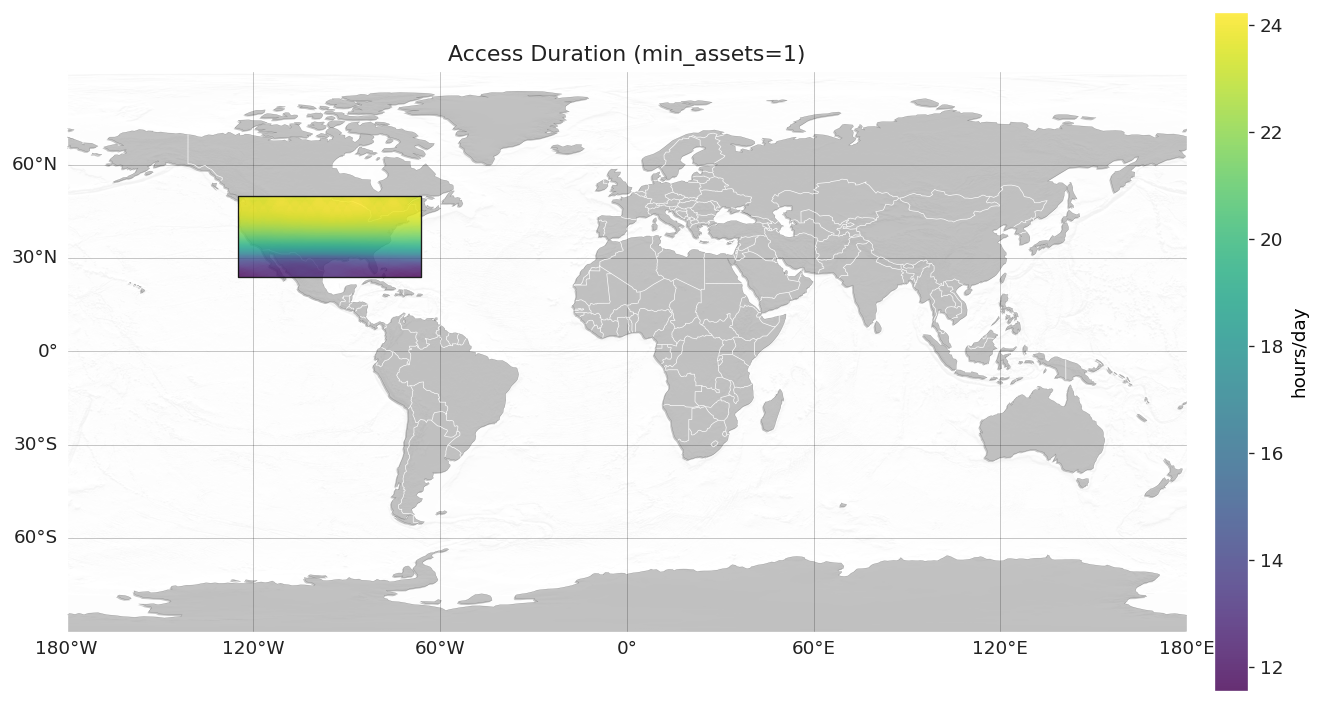

In [13]:
# Replace these orbit-generated positions with your own external ephemeris arrays in real use.
ephemeris_observers = [
    Observer.from_tabulated(
        timeline.absolute_time,
        orbit.get_p_np(timeline.absolute_time, frame="itrf"),
        name=f"tabulated-{idx:02d}",
    )
    for idx, orbit in enumerate(orbits, start=1)
]

sampled_example = Observer.from_samples(
    orbits[0].get_p_np(timeline.absolute_time, frame="itrf"),
    name="sampled-example",
)

ephemeris_coverage = IntervalCoverage.compute(
    timeline=timeline,
    observers=ephemeris_observers,
    targets=targets_region,
)

ephemeris_access = ephemeris_coverage.access_duration(min_assets=1, normalize="day", unit="hours")

{
    "observer_count": len(ephemeris_observers),
    "sampled_example_name": sampled_example.name,
    "max_abs_difference_vs_orbit_access": float(np.max(np.abs(ephemeris_access.values - region_access.values))),
}

ephemeris_access.plot()


## 6. Country And Composite Coverage Targets

Use `CoverageTargets.country(...)` when you want one Natural Earth country outline.
Use `CoverageTargets.union(...)` when you want to merge several countries, add a regular box, or reuse existing target regions before sampling.
The example below unions Japan, the Philippines, and one extra rectangular box, then derives the map extent from the sampled targets.


In [14]:
composite_targets = CoverageTargets.union(
    ["Japan", "Philippines","Taiwan"],
    BBoxDomain(
        west_deg=145.0,
        east_deg=160.0,
        south_deg=10.0,
        north_deg=30.0,
    ),
    sampler=LatitudeLongitudeSampler(nlats=201, nlons=241),
    resolution="10m",
    name="Japan, Philippines, Taiwan, and East China Sea Box",
)

composite_extent = composite_targets.extent(pad_deg=2.0)

composite_map_cfg = replace(
    LIGHT_DETAILED,
    extent=ExtentConfig(global_map=False, extent=composite_extent),
)

coverage_composite = IntervalCoverage.from_orbits(
    orbits=orbits,
    timeline=timeline,
    targets=composite_targets,
)

composite_access = coverage_composite.access_duration(min_assets=1, normalize="day", unit="hours")

{
    "n_composite_targets": composite_targets.n_targets,
    "target_extent": composite_extent,
    "access_hours_per_day": composite_access.summary(),
}


{'n_composite_targets': 9948,
 'target_extent': (114.95492597700002,
  162.0,
  2.6557070980000503,
  47.520412502000056),
 'access_hours_per_day': {'min': 11.110787073771158,
  'max': 23.73435601510637,
  'mean': 13.39161317805479,
  'std': 2.8169160500874635}}

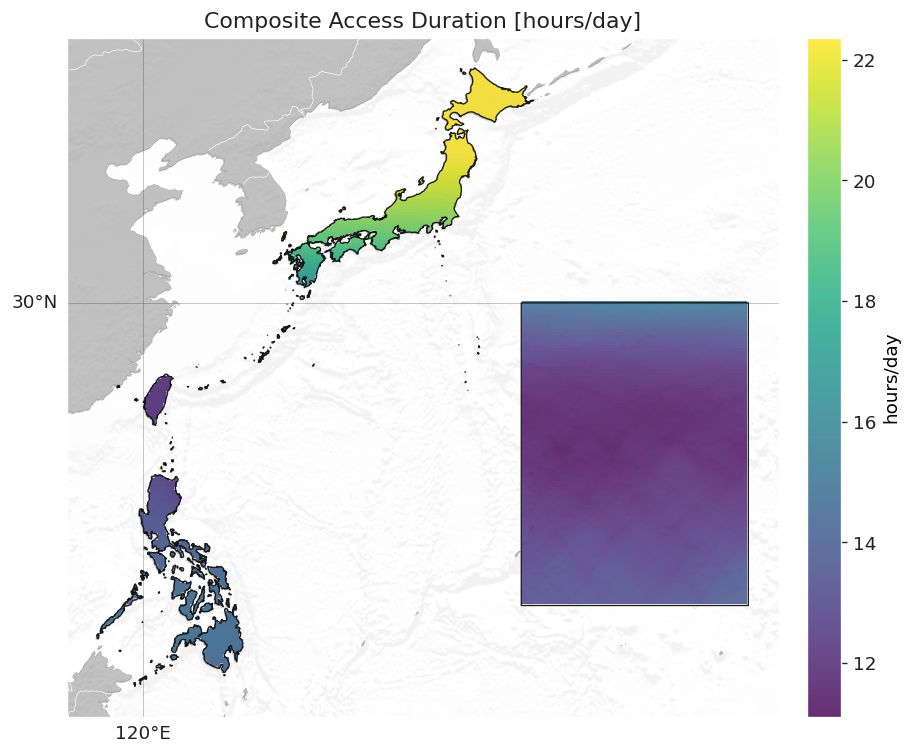

In [15]:
fig, _, _, _ = composite_access.plot(
    map_cfg=composite_map_cfg,
    title="Composite Access Duration [hours/day]",
    cmap="viridis",
    vmax=np.nanpercentile(composite_access.values, 97.0),
)
plt.show()


## 7. Target Definition Quick Reference

Every helper below returns a `CoverageTargets` object that you can pass straight into `IntervalCoverage.from_orbits(...)` or `IntervalCoverage.compute(...)`.
Each target set also exposes `targets.extent(...)`, so you can build `ExtentConfig` values without hand-writing longitude and latitude bounds.
This final reference cell shows the common target-definition patterns side by side: worldwide, land-only, ocean-only, a rectangular box, one country, multiple countries, and a mixed country-plus-box union.

For custom files or shapely geometries, use `CoverageTargets.from_geojson(...)`, `CoverageTargets.from_shapefile(...)`, or `CoverageTargets.from_domain(...)`.


In [16]:
target_examples = {
    "worldwide": CoverageTargets.global_earth(
        sampler=LatitudeAdaptiveSampler(nlats=91, nlons_equator=161),
    ),
    "land_only": CoverageTargets.land(
        sampler=LatitudeAdaptiveSampler(nlats=200, nlons_equator=300),
        resolution="10m",
    ),
    "ocean_only": CoverageTargets.ocean(
        sampler=LatitudeAdaptiveSampler(nlats=200, nlons_equator=300),
        resolution="10m",
    ),
    "regional_box": CoverageTargets.region_bbox(
        west_deg=-125.0,
        east_deg=-66.0,
        south_deg=24.0,
        north_deg=50.0,
        sampler=LatitudeLongitudeSampler(nlats=91, nlons=181),
    ),
    "single_country": CoverageTargets.country(
        "Japan",
        sampler=LatitudeLongitudeSampler(nlats=131, nlons=201),
        resolution="10m",
    ),
    "multiple_countries": CoverageTargets.countries(
        ["Japan", "Philippines"],
        sampler=LatitudeLongitudeSampler(nlats=131, nlons=221),
        resolution="10m",
    ),
    "country_plus_box": CoverageTargets.union(
        ["Japan", "Philippines"],
        BBoxDomain(
            west_deg=130.0,
            east_deg=145.0,
            south_deg=30.0,
            north_deg=38.0,
        ),
        sampler=LatitudeLongitudeSampler(nlats=131, nlons=221),
        resolution="10m",
        name="Japan, Philippines, and East China Sea Box",
    ),
}


## 8. Coverage For Each Target Definition

Now that `target_examples` holds a few common target-definition patterns, we can run the same constellation and timeline against each one.
The two cells below compute `access_duration(min_assets=1, normalize="day", unit="hours")` for every target set and then plot each result with an automatically chosen extent.


In [17]:
def target_example_map_cfg(name: str, targets: CoverageTargets):
    if name in {"worldwide", "land_only", "ocean_only"}:
        return LIGHT_DETAILED
    return replace(
        LIGHT_DETAILED,
        extent=ExtentConfig(global_map=False, extent=targets.extent(pad_deg=2.0)),
    )


target_example_coverages = {
    name: IntervalCoverage.from_orbits(
        orbits=orbits,
        timeline=timeline,
        targets=targets,
    )
    for name, targets in target_examples.items()
}

target_example_access = {
    name: coverage.access_duration(min_assets=1, normalize="day", unit="hours")
    for name, coverage in target_example_coverages.items()
}

target_example_access_summary = [
    {
        "definition": name,
        "n_targets": target_examples[name].n_targets,
        "extent_with_2deg_pad": tuple(round(value, 1) for value in target_examples[name].extent(pad_deg=2.0)),
        "access_hours_per_day": field.summary(),
    }
    for name, field in target_example_access.items()
]

target_example_access_summary


[{'definition': 'worldwide',
  'n_targets': 9223,
  'extent_with_2deg_pad': (-180.0, 180.0, -90.0, 90.0),
  'access_hours_per_day': {'min': 0.0,
   'max': 24.252246548889808,
   'mean': 15.635577696907635,
   'std': 5.402056903180036}},
 {'definition': 'land_only',
  'n_targets': 11320,
  'extent_with_2deg_pad': (-180.0, 180.0, -90.0, 85.6),
  'access_hours_per_day': {'min': 0.0,
   'max': 24.28285535176595,
   'mean': 14.9495384912665,
   'std': 6.029656883655108}},
 {'definition': 'ocean_only',
  'n_targets': 27094,
  'extent_with_2deg_pad': (-180.0, 180.0, -90.0, 90.0),
  'access_hours_per_day': {'min': 0.0,
   'max': 24.261923365439138,
   'mean': 15.906842574281729,
   'std': 5.115117949493987}},
 {'definition': 'regional_box',
  'n_targets': 16471,
  'extent_with_2deg_pad': (-127.0, -64.0, 22.0, 52.0),
  'access_hours_per_day': {'min': 11.540900548299154,
   'max': 24.254054571992608,
   'mean': 19.636343549881065,
   'std': 4.201328137479333}},
 {'definition': 'single_country',


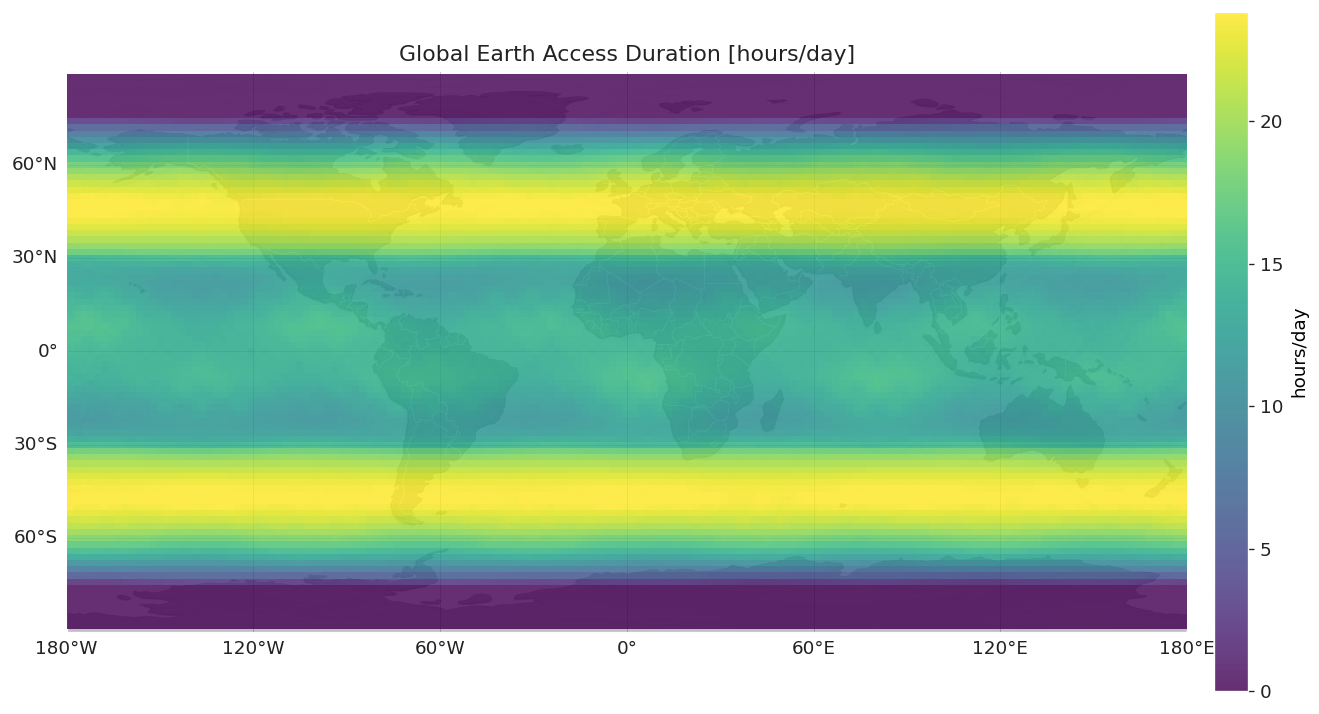

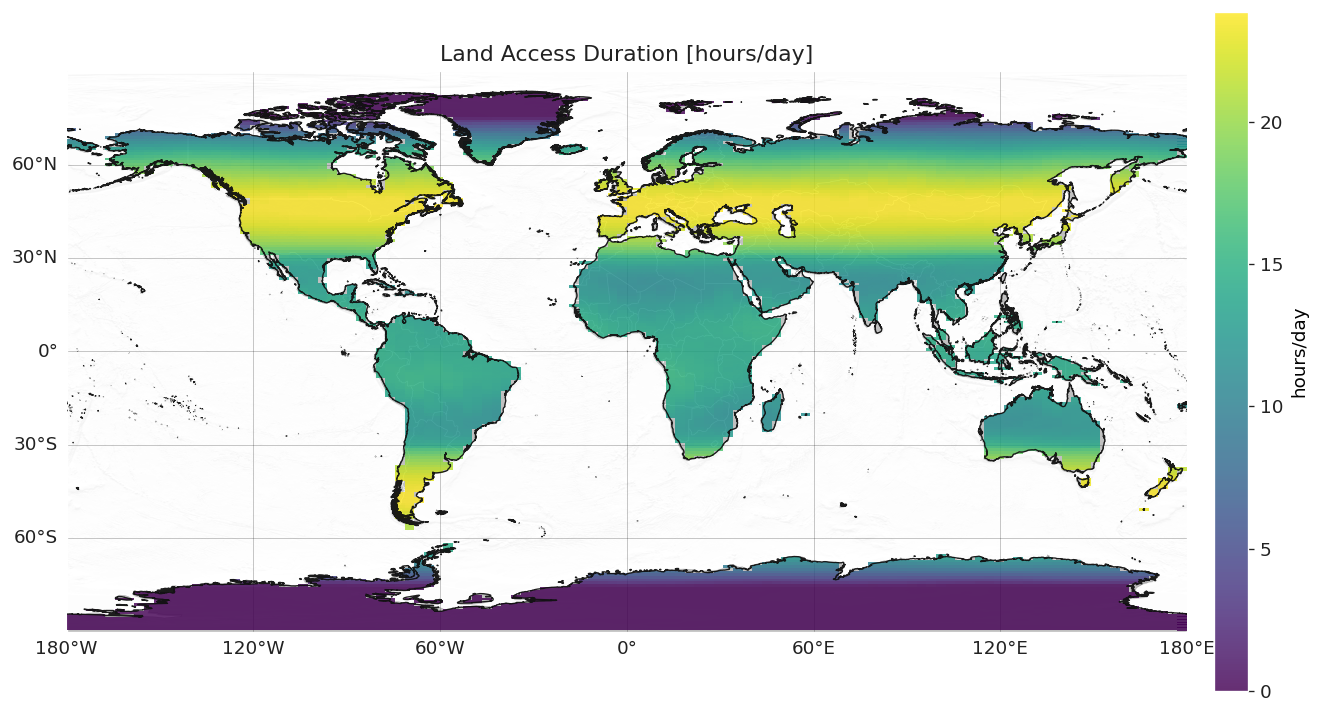

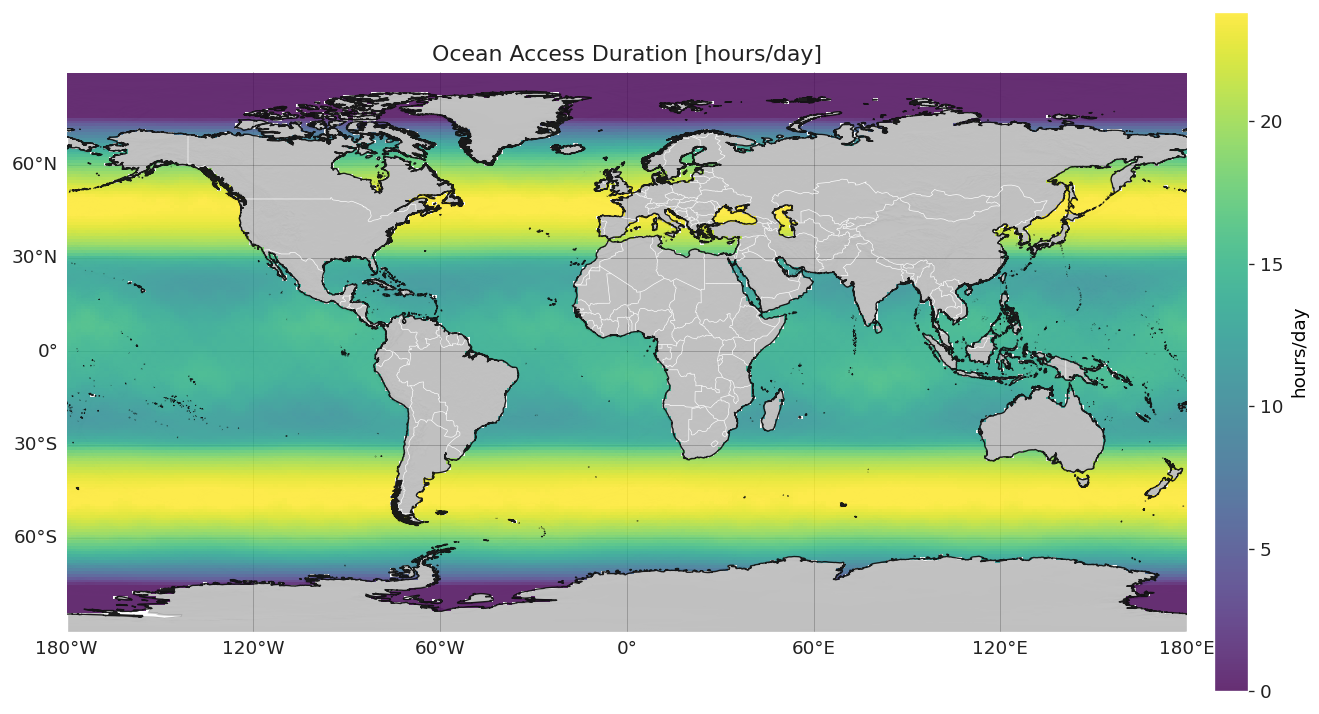

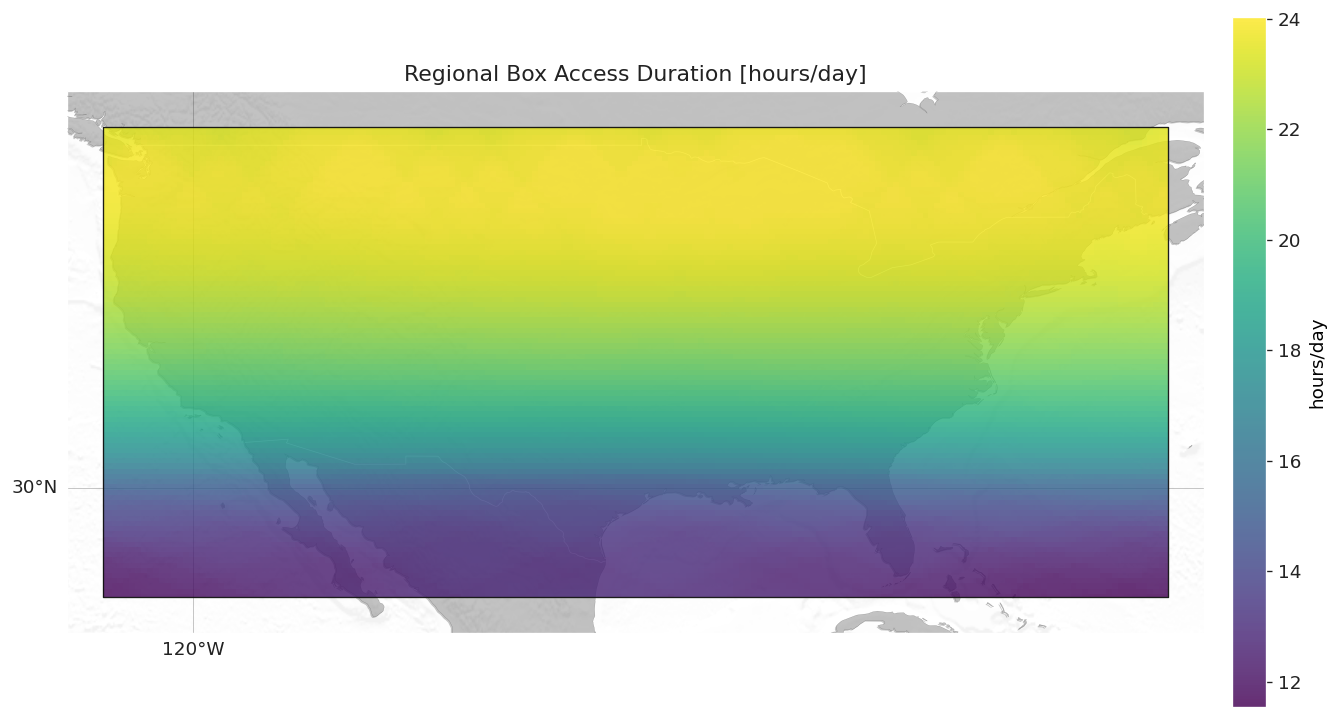

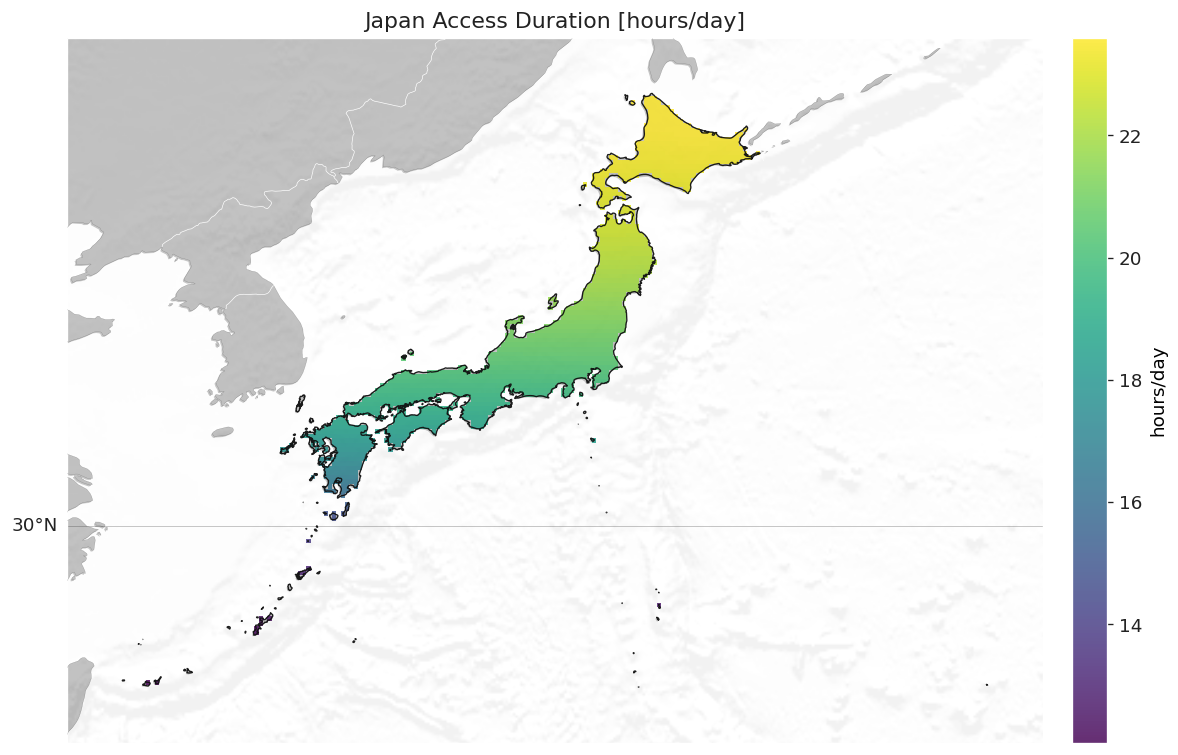

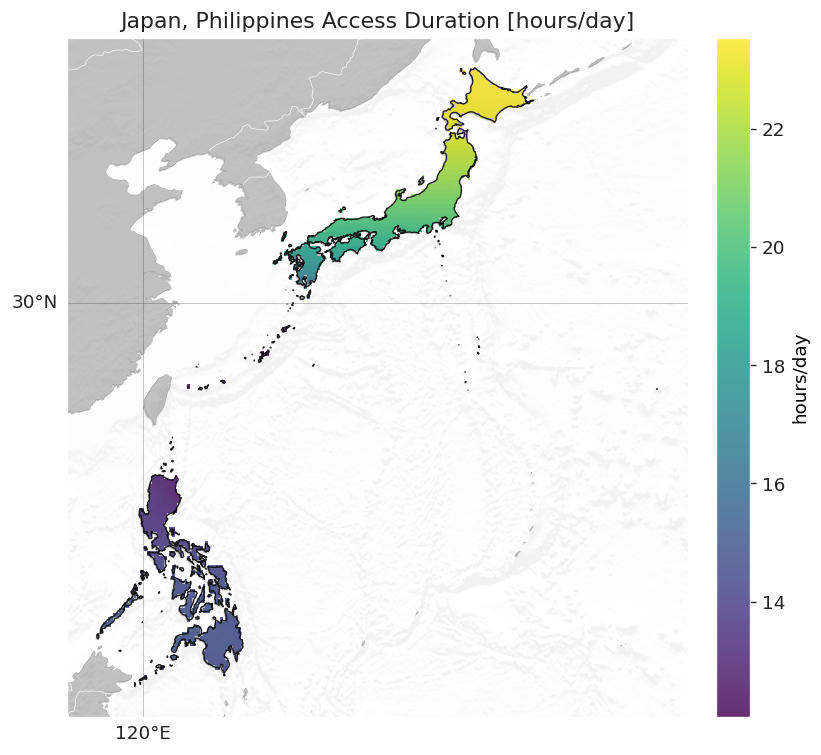

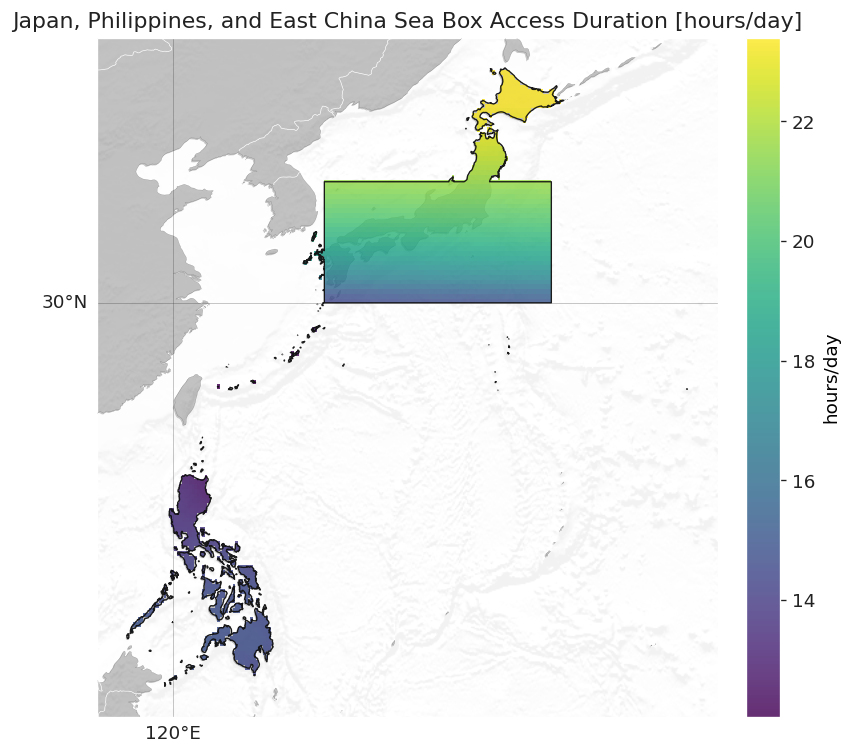

In [18]:
for name, field in target_example_access.items():
    title_label = target_examples[name].attrs.get("domain") or name.replace("_", " ").title()
    fig, _, _, _ = field.plot(
        map_cfg=target_example_map_cfg(name, target_examples[name]),
        title=f"{title_label} Access Duration [hours/day]",
        cmap="viridis",
        vmax=np.nanpercentile(field.values, 97.0),
    )
    plt.show()
